In [1]:
from openai import AzureOpenAI

client = AzureOpenAI(
    api_key="4ji4iP9qKL06gR2Z3lSEuSE8jm7KOqFRgu7vlHtEdJrHUwCfOXtsJQQJ99CDACNns7RXJ3w3AAABACOGPn3O",
    api_version="2024-02-01",
    azure_endpoint="https://projekjudol.openai.azure.com/"
)

resp = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": "Balas hanya dengan kata: OK"}],
    max_tokens=10
)
print(resp.choices[0].message.content)

OK


In [2]:
# -*- coding: utf-8 -*-
"""
02_generate_and_augment.py
JudolGuard — Synthetic Data Generator + Augmentor
===================================================
STRATEGI:
  1. Generate 20 akun "seed" via Azure OpenAI (~25.000 tokens)
  2. Augment jadi 200 akun via Python (variasi noise)
  3. Build behavioral features
  4. Output: ~8.000-12.000 baris siap training

SETUP SEBELUM RUN:
  - Ganti AZURE_API_KEY dan AZURE_ENDPOINT di bagian CONFIG
  - Pastikan folder data/ sudah ada: os.makedirs('data', exist_ok=True)
"""

# ─────────────────────────────────────────────────────────
# 0. INSTALL & IMPORT
# ─────────────────────────────────────────────────────────
# !pip install openai pandas numpy matplotlib seaborn scikit-learn

import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import AzureOpenAI

os.makedirs('data', exist_ok=True)

# ─────────────────────────────────────────────────────────
# 1. CONFIG — GANTI BAGIAN INI
# ─────────────────────────────────────────────────────────
AZURE_API_KEY      = "4ji4iP9qKL06gR2Z3lSEuSE8jm7KOqFRgu7vlHtEdJrHUwCfOXtsJQQJ99CDACNns7RXJ3w3AAABACOGPn3O"
AZURE_ENDPOINT     = "https://projekjudol.openai.azure.com/"   # contoh: https://projekjudol.openai.azure.com/
DEPLOYMENT_NAME    = "gpt-4o"                        # sesuai screenshot kamu

SEED_PER_PROFILE   = 5     # 5 akun × 4 profil = 20 API calls total
AUGMENT_MULTIPLIER = 10    # tiap seed akun → 10 variasi = 200 akun total

client = AzureOpenAI(
    api_key=AZURE_API_KEY,
    api_version="2024-02-01",
    azure_endpoint=AZURE_ENDPOINT
)

# ─────────────────────────────────────────────────────────
# 2. PROMPT PER PROFIL
# ─────────────────────────────────────────────────────────
PROMPTS = {

"normal": """
Generate data transaksi e-wallet untuk 1 pengguna NORMAL (tidak berjudi).
Karakteristik:
- 2-4 transaksi/hari, jam 07:00-21:00 (step % 24 antara 7-21)
- Amount Rp15.000-400.000 per transaksi
- Penerima konsisten: merchant, keluarga, tagihan
- Tidak ada pola aneh

Generate tepat 28 transaksi (28 hari).
Kembalikan HANYA JSON array, tanpa teks lain, tanpa markdown:
[{"step":<int 1-672>,"amount":<float>,"type":<"TRANSFER"|"PAYMENT"|"TOP_UP">,"recipient":<"merchant"|"family"|"utility">,"channel":<"ewallet"|"transfer">,"is_gambling":false}]
""",

"early_stage": """
Generate data transaksi e-wallet untuk 1 pengguna yang BARU MULAI judi online (14 hari pertama).
Karakteristik:
- Hari 1-7: normal (3-5 tx/hari, jam 07-21)
- Hari 8-14: mulai ada 2-3 transaksi judol kecil (Rp50k-150k), sesekali jam 22-23
- Penerima mulai ada "unknown_agent" 1-2x

Generate tepat 35 transaksi.
Kembalikan HANYA JSON array:
[{"step":<int 1-336>,"amount":<float>,"type":<"TRANSFER"|"PAYMENT"|"TOP_UP">,"recipient":<"merchant"|"family"|"utility"|"unknown_agent">,"channel":<"ewallet"|"qris"|"transfer">,"is_gambling":<bool>}]
""",

"escalating": """
Generate data transaksi e-wallet untuk 1 pengguna yang ESKALASI judi online (42 hari).
PENTING: Harus ada perubahan pola yang jelas dari minggu 1 ke minggu 6:
- Minggu 1-2: normal (3-4 tx/hari, jam 07-21, amount Rp50k-300k)
- Minggu 3-4: mulai shift (5-8 tx/hari, jam 20-02 mulai dominan, amount turun Rp20k-80k)
- Minggu 5-6: eskalasi penuh (10-15 tx/hari, jam 22-04 dominan, smurfing Rp10k-50k, banyak penerima baru)
Ini adalah BEHAVIORAL SHIFT yang paling penting dideteksi.

Generate tepat 55 transaksi.
Kembalikan HANYA JSON array:
[{"step":<int 1-1008>,"amount":<float>,"type":<"TRANSFER"|"PAYMENT"|"TOP_UP"|"WITHDRAWAL">,"recipient":<"merchant"|"family"|"gambling_agent"|"money_mule"|"unknown_agent">,"channel":<"ewallet"|"qris"|"transfer">,"is_gambling":<bool>}]
""",

"heavy_gambler": """
Generate data transaksi e-wallet untuk 1 pengguna HEAVY GAMBLER (14 hari, sudah adiktif penuh).
Karakteristik:
- 15-25 tx/hari, mayoritas jam 23-05
- Semua transfer ke gambling_agent dipecah Rp10k-50k (smurfing)
- 20-30 penerima unik per minggu
- Drain cycle: TOP_UP → habis <2 jam → TOP_UP lagi
- Mayoritas channel QRIS

Generate tepat 45 transaksi.
Kembalikan HANYA JSON array:
[{"step":<int 1-336>,"amount":<float>,"type":<"TRANSFER"|"PAYMENT"|"TOP_UP"|"WITHDRAWAL">,"recipient":<"gambling_agent"|"money_mule"|"pinjol"|"merchant">,"channel":<"ewallet"|"qris">,"is_gambling":<bool>}]
"""
}

PROFILE_LABEL = {
    "normal": 0,
    "early_stage": 0,       # belum at_risk
    "escalating": 1,        # TARGET DETEKSI DINI
    "heavy_gambler": 1
}

# ─────────────────────────────────────────────────────────
# 3. AZURE GENERATOR — 20 SEED ACCOUNTS
# ─────────────────────────────────────────────────────────
def generate_seed(profile: str, account_id: str) -> list:
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model=DEPLOYMENT_NAME,
                messages=[
                    {"role": "system", "content": "Kamu generator data sintetis. Selalu kembalikan HANYA JSON array valid, tanpa markdown, tanpa penjelasan apapun."},
                    {"role": "user", "content": PROMPTS[profile]}
                ],
                temperature=0.85,
                max_tokens=2500
            )
            raw = resp.choices[0].message.content.strip()
            # Bersihkan markdown jika ada
            if "```" in raw:
                raw = raw.split("```")[1]
                if raw.startswith("json"):
                    raw = raw[4:]
            raw = raw.strip()

            txs = json.loads(raw)
            for tx in txs:
                tx['account_id'] = account_id
                tx['profile']    = profile
                tx['is_at_risk'] = PROFILE_LABEL[profile]
                tx['is_seed']    = True
            print(f"  ✓ {account_id} [{profile}]: {len(txs)} transaksi")
            return txs

        except json.JSONDecodeError:
            print(f"  ✗ {account_id} JSON error (attempt {attempt+1}), retry...")
            time.sleep(2)
        except Exception as e:
            print(f"  ✗ {account_id} Error: {e} (attempt {attempt+1}), retry...")
            time.sleep(3)
    print(f"  ✗ {account_id} GAGAL, dilewati.")
    return []


print("=" * 55)
print("  FASE 1: Generating 20 seed accounts via Azure OpenAI")
print("=" * 55)

seed_data = []
acc_counter = 1

for profile in ["normal", "early_stage", "escalating", "heavy_gambler"]:
    print(f"\n[{profile.upper()}] — {SEED_PER_PROFILE} akun")
    for i in range(SEED_PER_PROFILE):
        acc_id = f"SEED_{acc_counter:03d}"
        txs = generate_seed(profile, acc_id)
        seed_data.extend(txs)
        acc_counter += 1
        time.sleep(1.2)   # hindari rate limit

df_seed = pd.DataFrame(seed_data)
df_seed.to_csv('data/seed_accounts.csv', index=False)
print(f"\n Seed accounts tersimpan: {df_seed.shape[0]} transaksi dari {df_seed['account_id'].nunique()} akun")

  FASE 1: Generating 20 seed accounts via Azure OpenAI

[NORMAL] — 5 akun
  ✓ SEED_001 [normal]: 28 transaksi
  ✓ SEED_002 [normal]: 27 transaksi
  ✓ SEED_003 [normal]: 28 transaksi
  ✓ SEED_004 [normal]: 27 transaksi
  ✓ SEED_005 [normal]: 28 transaksi

[EARLY_STAGE] — 5 akun
  ✓ SEED_006 [early_stage]: 35 transaksi
  ✓ SEED_007 [early_stage]: 26 transaksi
  ✓ SEED_008 [early_stage]: 34 transaksi
  ✓ SEED_009 [early_stage]: 34 transaksi
  ✓ SEED_010 [early_stage]: 34 transaksi

[ESCALATING] — 5 akun
  ✓ SEED_011 [escalating]: 53 transaksi
  ✓ SEED_012 [escalating]: 52 transaksi
  ✓ SEED_013 [escalating]: 55 transaksi
  ✓ SEED_014 [escalating]: 55 transaksi
  ✓ SEED_015 [escalating]: 55 transaksi

[HEAVY_GAMBLER] — 5 akun
  ✓ SEED_016 [heavy_gambler]: 45 transaksi
  ✓ SEED_017 [heavy_gambler]: 45 transaksi
  ✓ SEED_018 [heavy_gambler]: 44 transaksi
  ✓ SEED_019 [heavy_gambler]: 43 transaksi
  ✓ SEED_020 [heavy_gambler]: 45 transaksi

 Seed accounts tersimpan: 793 transaksi dari 20 akun

In [3]:
# Load seed yang sudah ada, skip Fase 1
df_seed = pd.read_csv('/content/data/seed_accounts.csv')
print(f"Seed loaded: {df_seed.shape[0]} transaksi dari {df_seed['account_id'].nunique()} akun")

Seed loaded: 793 transaksi dari 20 akun



  FASE 2: Augmenting 20 seed → 200 akun

Augmenting 20 seed accounts × 30 variasi...

Total transaksi setelah augmentasi: 24,583
Total akun: 620

Distribusi profil:
profile
early_stage      155
escalating       155
heavy_gambler    155
normal           155

  FASE 3: Building Behavioral Features

 Features dataset tersimpan: 24,583 baris × 24 kolom
Label distribusi:
is_at_risk
1    15252
0     9331

Imbalance ratio: 1:0

  FASE 4: Sanity Check Visualisasi


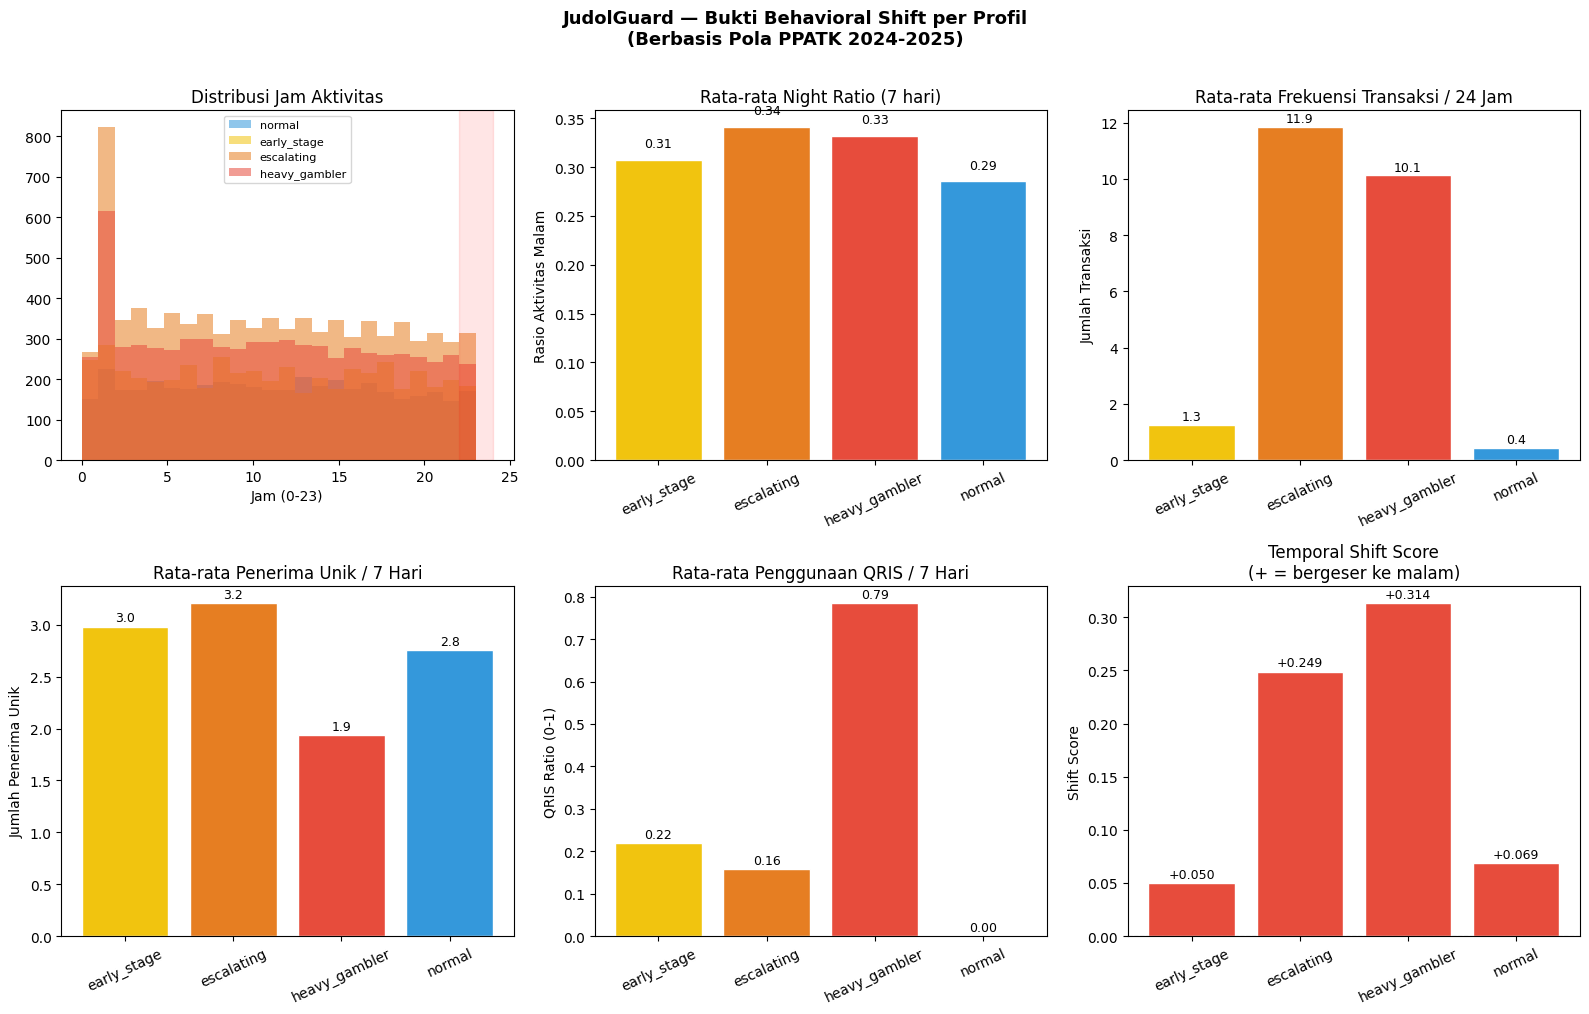


 Chart tersimpan: data/behavioral_shift_evidence.png

  SUMMARY DATASET FINAL
  File siap: data/judolguard_features.csv
  Total baris: 24,583
  Total akun : 620
  Features   : 24 kolom

  Distribusi profil:
    early_stage         155 akun |   5053 transaksi | NORMAL
    escalating          155 akun |   8370 transaksi | AT RISK
    heavy_gambler       155 akun |   6882 transaksi | AT RISK
    normal              155 akun |   4278 transaksi | NORMAL

  NEXT STEP:
  ── Notebook 03: Load data/judolguard_features.csv → Isolation Forest + XGBoost
  ── Notebook 04: Azure Anomaly Detector + Azure ML deployment
  ── App      : Streamlit dashboard



In [4]:
# ─────────────────────────────────────────────────────────
# 4. AUGMENTOR — DARI 20 SEED → 200 AKUN
# ─────────────────────────────────────────────────────────
# Logika: tiap seed akun menghasilkan AUGMENT_MULTIPLIER variasi
# Variasi = noise pada amount, step offset, channel swap
# Pola perilaku (profile) tetap identik → valid secara metodologis

print("\n" + "=" * 55)
print("  FASE 2: Augmenting 20 seed → 200 akun")
print("=" * 55)

def augment_account(df_original: pd.DataFrame, new_account_id: str, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    df = df_original.copy()
    df['account_id'] = new_account_id
    df['is_seed'] = False

    # 1. Noise pada amount (±20%)
    noise_factor = rng.uniform(0.80, 1.20, size=len(df))
    df['amount'] = (df['amount'] * noise_factor).round(0).clip(lower=1000)

    # 2. Shift step
    step_shift = rng.integers(-12, 12)
    df['step'] = (df['step'] + step_shift).clip(lower=1)

    # 3. Channel swap
    if df['profile'].iloc[0] in ['escalating', 'heavy_gambler']:
        swap_mask = rng.random(len(df)) < 0.10
        df.loc[swap_mask & (df['channel'] == 'ewallet'), 'channel'] = 'qris'

    # 4. Recipient variation — FIX: hitung mask gabungan dulu
    if df['profile'].iloc[0] == 'escalating':
        recipients = ['gambling_agent', 'money_mule', 'unknown_agent']
        swap_mask = rng.random(len(df)) < 0.08

        # ← INI YANG DIPERBAIKI: pakai combined_mask, bukan dua mask terpisah
        combined_mask = swap_mask & (df['is_gambling'] == True)
        n_to_replace = combined_mask.sum()

        if n_to_replace > 0:
            df.loc[combined_mask, 'recipient'] = rng.choice(recipients, size=n_to_replace)

    return df


augmented_all = [df_seed]  # mulai dari seed, tambahkan augmented

aug_counter = acc_counter
profile_groups = df_seed.groupby('account_id')

AUGMENT_MULTIPLIER = 30

print(f"\nAugmenting {df_seed['account_id'].nunique()} seed accounts × {AUGMENT_MULTIPLIER} variasi...\n")

for seed_acc_id, group in profile_groups:
    for i in range(AUGMENT_MULTIPLIER):
        new_id = f"AUG_{aug_counter:04d}"
        aug_df = augment_account(group, new_id, seed=aug_counter * 7 + i)
        augmented_all.append(aug_df)
        aug_counter += 1

df_full = pd.concat(augmented_all, ignore_index=True)
df_full = df_full.sort_values(['account_id', 'step']).reset_index(drop=True)

print(f"Total transaksi setelah augmentasi: {df_full.shape[0]:,}")
print(f"Total akun: {df_full['account_id'].nunique()}")
print(f"\nDistribusi profil:")
print(df_full.groupby('profile')['account_id'].nunique().to_string())


# ─────────────────────────────────────────────────────────
# 5. FEATURE ENGINEERING — BEHAVIORAL FEATURES
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  FASE 3: Building Behavioral Features")
print("=" * 55)

# Konversi tipe data
df_full['step']   = df_full['step'].astype(int)
df_full['amount'] = df_full['amount'].astype(float)

# Fitur dasar temporal
df_full['hour_of_day'] = df_full['step'] % 24
df_full['day']         = df_full['step'] // 24
df_full['is_night']    = ((df_full['hour_of_day'] >= 22) | (df_full['hour_of_day'] <= 4)).astype(int)

# Fitur per akun — rolling window
feature_rows = []

for acc_id, group in df_full.groupby('account_id'):
    group = group.sort_values('step').reset_index(drop=True)

    for i, row in group.iterrows():
        s = row['step']

        w24  = group[(group['step'] >= s - 24)  & (group['step'] < s)]
        w7d  = group[(group['step'] >= s - 168) & (group['step'] < s)]
        w14d = group[(group['step'] >= s - 336) & (group['step'] < s)]

        # ── Temporal features ──
        tx_24h       = len(w24)
        tx_7d        = len(w7d)
        night_r_7d   = w7d['is_night'].mean()    if len(w7d)  > 0 else 0.0
        night_r_14d  = w14d['is_night'].mean()   if len(w14d) > 0 else 0.0

        # ── Velocity features ──
        avg_amt_7d   = w7d['amount'].mean()      if len(w7d)  > 0 else row['amount']
        amt_ratio    = row['amount'] / avg_amt_7d if avg_amt_7d > 0 else 1.0
        total_amt_7d = w7d['amount'].sum()        if len(w7d)  > 0 else 0.0

        # Frekuensi naik dari 7 hari ke 24 jam (velocity burst)
        avg_daily_7d = (tx_7d / 7) if tx_7d > 0 else 0
        burst_score  = tx_24h / avg_daily_7d if avg_daily_7d > 0 else 0.0

        # ── Multi-recipient features ──
        unique_recv_7d  = w7d['recipient'].nunique()  if len(w7d)  > 0 else 0
        unique_recv_24h = w24['recipient'].nunique()  if len(w24)  > 0 else 0

        # ── Channel features ──
        qris_r_7d = (w7d['channel'] == 'qris').mean() if len(w7d) > 0 else 0.0

        # ── Drain cycle: top up ≥2 kali dalam 24 jam + frekuensi tinggi ──
        topup_24h   = (w24['type'] == 'TOP_UP').sum() if len(w24) > 0 else 0
        drain_flag  = 1 if (topup_24h >= 2 and tx_24h >= 6) else 0

        # ── Dormant flag ──
        pre_14d     = group[group['step'] < s - 336]
        dormant_flag = 1 if (len(pre_14d) > 0 and tx_7d == 0 and tx_24h > 0) else 0

        # ── SHIFT SCORE — fitur kunci untuk narasi behavioral shift ──
        # Bandingkan night_ratio 7 hari terakhir vs 7 hari sebelumnya
        w7d_prev     = group[(group['step'] >= s - 336) & (group['step'] < s - 168)]
        night_prev   = w7d_prev['is_night'].mean() if len(w7d_prev) > 0 else 0.0
        shift_score  = round(night_r_7d - night_prev, 4)   # positif = bergeser ke malam

        feature_rows.append({
            # Identitas
            'account_id'        : acc_id,
            'step'              : s,
            'day'               : row['day'],
            'profile'           : row['profile'],
            'is_at_risk'        : row['is_at_risk'],

            # Temporal
            'hour_of_day'       : row['hour_of_day'],
            'is_night'          : row['is_night'],
            'night_ratio_7d'    : round(night_r_7d, 4),
            'night_ratio_14d'   : round(night_r_14d, 4),
            'temporal_shift'    : shift_score,

            # Velocity
            'amount'            : row['amount'],
            'amount_log'        : round(np.log1p(row['amount']), 4),
            'amount_vs_avg_7d'  : round(amt_ratio, 4),
            'total_amount_7d'   : round(total_amt_7d, 2),
            'tx_count_24h'      : tx_24h,
            'tx_count_7d'       : tx_7d,
            'burst_score'       : round(burst_score, 4),

            # Multi-recipient
            'unique_recv_7d'    : unique_recv_7d,
            'unique_recv_24h'   : unique_recv_24h,

            # Channel
            'qris_ratio_7d'     : round(qris_r_7d, 4),
            'channel'           : row['channel'],

            # Behavioral flags
            'drain_cycle_flag'  : drain_flag,
            'dormant_flag'      : dormant_flag,
            'is_gambling'       : int(row.get('is_gambling', False)),
        })

df_features = pd.DataFrame(feature_rows)
df_features.to_csv('data/judolguard_features.csv', index=False)

print(f"\n Features dataset tersimpan: {df_features.shape[0]:,} baris × {df_features.shape[1]} kolom")
print(f"Label distribusi:")
print(df_features['is_at_risk'].value_counts().to_string())
print(f"\nImbalance ratio: 1:{int(df_features['is_at_risk'].eq(0).sum() / max(df_features['is_at_risk'].eq(1).sum(),1))}")


# ─────────────────────────────────────────────────────────
# 6. SANITY CHECK — VISUALISASI BEHAVIORAL SHIFT
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  FASE 4: Sanity Check Visualisasi")
print("=" * 55)

palette = {
    'normal'       : '#3498db',
    'early_stage'  : '#f1c40f',
    'escalating'   : '#e67e22',
    'heavy_gambler': '#e74c3c'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('JudolGuard — Bukti Behavioral Shift per Profil\n(Berbasis Pola PPATK 2024-2025)',
             fontsize=13, fontweight='bold', y=1.01)

# 1. Distribusi jam aktivitas
for p, c in palette.items():
    d = df_features[df_features['profile'] == p]['hour_of_day']
    axes[0,0].hist(d, bins=24, alpha=0.55, label=p, color=c, range=(0,23))
axes[0,0].set_title('Distribusi Jam Aktivitas')
axes[0,0].set_xlabel('Jam (0-23)')
axes[0,0].legend(fontsize=8)
axes[0,0].axvspan(22, 24, alpha=0.1, color='red', label='Jam malam')

# 2. Rata-rata night ratio
means_night = df_features.groupby('profile')['night_ratio_7d'].mean()
bars = axes[0,1].bar(means_night.index, means_night.values,
                     color=[palette[p] for p in means_night.index], edgecolor='white')
axes[0,1].set_title('Rata-rata Night Ratio (7 hari)')
axes[0,1].set_ylabel('Rasio Aktivitas Malam')
axes[0,1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, means_night.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 3. Rata-rata frekuensi transaksi 24 jam
means_tx = df_features.groupby('profile')['tx_count_24h'].mean()
bars2 = axes[0,2].bar(means_tx.index, means_tx.values,
                      color=[palette[p] for p in means_tx.index], edgecolor='white')
axes[0,2].set_title('Rata-rata Frekuensi Transaksi / 24 Jam')
axes[0,2].set_ylabel('Jumlah Transaksi')
axes[0,2].tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, means_tx.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# 4. Rata-rata unique recipients 7 hari
means_recv = df_features.groupby('profile')['unique_recv_7d'].mean()
bars3 = axes[1,0].bar(means_recv.index, means_recv.values,
                      color=[palette[p] for p in means_recv.index], edgecolor='white')
axes[1,0].set_title('Rata-rata Penerima Unik / 7 Hari')
axes[1,0].set_ylabel('Jumlah Penerima Unik')
axes[1,0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars3, means_recv.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# 5. QRIS ratio per profil
means_qris = df_features.groupby('profile')['qris_ratio_7d'].mean()
bars4 = axes[1,1].bar(means_qris.index, means_qris.values,
                      color=[palette[p] for p in means_qris.index], edgecolor='white')
axes[1,1].set_title('Rata-rata Penggunaan QRIS / 7 Hari')
axes[1,1].set_ylabel('QRIS Ratio (0-1)')
axes[1,1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars4, means_qris.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 6. Temporal shift score — INI YANG PALING PENTING
means_shift = df_features.groupby('profile')['temporal_shift'].mean()
colors_shift = ['#27ae60' if v <= 0 else '#e74c3c' for v in means_shift.values]
bars5 = axes[1,2].bar(means_shift.index, means_shift.values,
                      color=colors_shift, edgecolor='white')
axes[1,2].set_title('Temporal Shift Score\n(+ = bergeser ke malam)')
axes[1,2].set_ylabel('Shift Score')
axes[1,2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1,2].tick_params(axis='x', rotation=25)
for bar, val in zip(bars5, means_shift.values):
    offset = 0.002 if val >= 0 else -0.008
    axes[1,2].text(bar.get_x() + bar.get_width()/2, val + offset,
                   f'{val:+.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/behavioral_shift_evidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Chart tersimpan: data/behavioral_shift_evidence.png")

# ─────────────────────────────────────────────────────────
# 7. SUMMARY AKHIR
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SUMMARY DATASET FINAL")
print("=" * 55)
print(f"  File siap: data/judolguard_features.csv")
print(f"  Total baris: {df_features.shape[0]:,}")
print(f"  Total akun : {df_features['account_id'].nunique()}")
print(f"  Features   : {df_features.shape[1]} kolom")
print(f"\n  Distribusi profil:")
for p, g in df_features.groupby('profile'):
    n_acc = g['account_id'].nunique()
    n_tx  = len(g)
    label = "AT RISK" if PROFILE_LABEL[p] == 1 else "NORMAL"
    print(f"    {p:<18} {n_acc:>4} akun | {n_tx:>6} transaksi | {label}")

print(f"""
  NEXT STEP:
  ── Notebook 03: Load data/judolguard_features.csv → Isolation Forest + XGBoost
  ── Notebook 04: Azure Anomaly Detector + Azure ML deployment
  ── App      : Streamlit dashboard
""")

In [5]:
df_final = pd.read_csv('/content/data/judolguard_features.csv')

In [6]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24583 entries, 0 to 24582
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account_id        24583 non-null  object 
 1   step              24583 non-null  int64  
 2   day               24583 non-null  int64  
 3   profile           24583 non-null  object 
 4   is_at_risk        24583 non-null  int64  
 5   hour_of_day       24583 non-null  int64  
 6   is_night          24583 non-null  int64  
 7   night_ratio_7d    24583 non-null  float64
 8   night_ratio_14d   24583 non-null  float64
 9   temporal_shift    24583 non-null  float64
 10  amount            24583 non-null  float64
 11  amount_log        24583 non-null  float64
 12  amount_vs_avg_7d  24583 non-null  float64
 13  total_amount_7d   24583 non-null  float64
 14  tx_count_24h      24583 non-null  int64  
 15  tx_count_7d       24583 non-null  int64  
 16  burst_score       24583 non-null  float6

In [7]:
print(df_final['profile'].unique())

['normal' 'early_stage' 'escalating' 'heavy_gambler']


In [8]:
df_seed = pd.read_csv('data/seed_accounts.csv')

print("Distribusi label:")
print(df_seed.groupby(['profile', 'is_at_risk'])['account_id'].nunique())

print(f"\nRasio at_risk:")
at_risk = df_seed['is_at_risk'].mean() * 100
print(f"  At risk  : {at_risk:.1f}%")
print(f"  Not risk : {100-at_risk:.1f}%")

Distribusi label:
profile        is_at_risk
early_stage    0             5
escalating     1             5
heavy_gambler  1             5
normal         0             5
Name: account_id, dtype: int64

Rasio at_risk:
  At risk  : 62.0%
  Not risk : 38.0%
